# VGG-style StandardCNN — Tiny ImageNet 200

In [ ]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Set RESUME=True only if latest_checkpoint.pth is available at LATEST_PATH.
RESUME = False

# ---------------- EXPERIMENT CONFIGURATION ----------------
SEED = 42
NUM_CLASSES = 200
TRAIN_PER_CLASS = 450
VAL_PER_CLASS = 100
BATCH_SIZE = 64
NUM_WORKERS = 4
EPOCHS = 100
EARLY_STOPPING_PATIENCE = 15

# SGD + Momentum + Nesterov
INITIAL_LR = 0.05
WEIGHT_DECAY = 1e-4
MIN_LR = 1e-5

LABEL_SMOOTHING = 0.1
CLASSIFIER_DROPOUT = 0.5
CLEAN_EVAL_INTERVAL = 5

SAVE_DIR = Path("checkpoints_leaky_relu/vgg_8layer_flatten_fc")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)
print("DataLoader workers:", NUM_WORKERS)

## 1. Local model and reference dataset loader

In [2]:
# Run this notebook from your project root (where src/ and model_fc.py are importable). Verify that model_fc.py defines the intended Flatten + FC StandardCNN before starting.
# If model_fc.py is inside cnn_exp/, change the import to: from cnn_exp.model_fc import StandardCNN
from z_cnn_experiment.vgg_cnn.leaky_relu.model_leaky_relu import StandardCNN  # Flatten + FC architecture; adjust if your module has a different path
from src.dataset._balance_class_subset import BalancedClassSubset
from src.dataset.tiny_imagenet_dataset_2 import (
    TinyImageNetLoader, show_image, get_tiny_imagenet_class_names, means, stds, convert_to_rgb
)

TINY_ROOT = Path('../../../../data/tiny_imagenet/tiny-imagenet-200-450train-100val')
SELECTED_CLASSES = list(range(NUM_CLASSES))
print('Dataset root:', TINY_ROOT)

Dataset root: ../../data/tiny_imagenet/tiny-imagenet-200-450train-100val


In [3]:
# RandAugment(3,7) experiment: no PCA RGB, classifier dropout 0.5. Keep this pipeline unchanged for controlled comparison.
train_tf = transforms.Compose([
    transforms.Lambda(convert_to_rgb),
    transforms.RandomCrop(64, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandAugment(num_ops=3, magnitude=7),
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds),
])

test_tf = transforms.Compose([
    transforms.Lambda(convert_to_rgb),
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds)
])
train_dataset, val_dataset, _, _ = TinyImageNetLoader(seed=SEED, root=TINY_ROOT, train_transform=train_tf, test_transform=test_tf).load()
clean_train_dataset, _, _, _ = TinyImageNetLoader(seed=SEED, root=TINY_ROOT, train_transform=test_tf, test_transform=test_tf).load()
if not hasattr(clean_train_dataset, 'transform'):
    raise AttributeError('Expected the dataset to expose a transform attribute.')
train_subset = BalancedClassSubset(train_dataset, SELECTED_CLASSES, TRAIN_PER_CLASS, seed=SEED)
clean_train_subset = BalancedClassSubset(clean_train_dataset, SELECTED_CLASSES, TRAIN_PER_CLASS, seed=SEED)
val_subset = BalancedClassSubset(val_dataset, SELECTED_CLASSES, VAL_PER_CLASS, seed=SEED + 1)
assert train_subset.samples == clean_train_subset.samples, 'Clean and augmented training subsets differ.'
assert len(train_subset) == NUM_CLASSES * TRAIN_PER_CLASS
assert len(val_subset) == NUM_CLASSES * VAL_PER_CLASS
FULL_CLASS_NAMES = get_tiny_imagenet_class_names(train_dataset, TINY_ROOT)
CLASS_NAMES = [FULL_CLASS_NAMES[i] for i in SELECTED_CLASSES]
print('Train:', len(train_subset), 'Validation:', len(val_subset))

Tiny ImageNet loaded
Classes: 200
Train images: 90000
Validation images: 20000
Test images: 10000
Tiny ImageNet loaded
Classes: 200
Train images: 90000
Validation images: 20000
Test images: 10000
Train: 90000 Validation: 20000


In [4]:
# Check the transforms actually attached to each dataset
for name, dataset in [
    ("Train", train_dataset),
    ("Clean Train", clean_train_dataset),
    ("Validation", val_dataset),
]:
    print(f"\n{name}:")
    print(getattr(dataset, "transform", "No direct transform attribute"))

    image, label = dataset[0]
    print(
        "Min:", image.min().item(),
        "Max:", image.max().item()
    )


Train:
Compose(
    Lambda()
    RandomCrop(size=(64, 64), padding=4)
    RandomHorizontalFlip(p=0.5)
    RandAugment(num_ops=3, magnitude=7, num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
    ToTensor()
    Normalize(mean=[0.4803270399570465, 0.44804883003234863, 0.3975021243095398], std=[0.27645865082740784, 0.26883983612060547, 0.28148162364959717])
)
Min: -1.7374281883239746 Max: 2.1404519081115723

Clean Train:
Compose(
    Lambda()
    ToTensor()
    Normalize(mean=[0.4803270399570465, 0.44804883003234863, 0.3975021243095398], std=[0.27645865082740784, 0.26883983612060547, 0.28148162364959717])
)
Min: -1.6665030717849731 Max: 2.042928695678711

Validation:
Compose(
    Lambda()
    ToTensor()
    Normalize(mean=[0.4803270399570465, 0.44804883003234863, 0.3975021243095398], std=[0.27645865082740784, 0.26883983612060547, 0.28148162364959717])
)
Min: -1.7374281883239746 Max: 2.1404519081115723


## 2. DataLoaders

In [5]:
# If macOS worker spawning fails, set NUM_WORKERS=0 in configuration.
loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
    "persistent_workers": NUM_WORKERS > 0,
    **({"prefetch_factor": 2} if NUM_WORKERS > 0 else {}),
}

train_loader = DataLoader(
    train_subset,
    shuffle=True,
    generator=loader_generator,
    **loader_options,
)
val_loader = DataLoader(val_subset, shuffle=False, **loader_options)
clean_train_loader = DataLoader(clean_train_subset, shuffle=False, **loader_options)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 1407
Validation batches: 313


## Visual Check

In [6]:
# NUM_SHOW = 5
#
# train_iter = iter(train_loader)
# clean_train_iter = iter(clean_train_loader)
# val_iter = iter(val_loader)

In [7]:
# train_images, train_labels = next(train_iter)
# clean_train_images, clean_train_labels = next(clean_train_iter)
# val_images, val_labels_batch = next(val_iter)
#
# show_image(train_images, train_labels, NUM_SHOW, CLASS_NAMES, name="Train Images", has_norm=True)
# show_image(clean_train_images, clean_train_labels, NUM_SHOW, CLASS_NAMES, name="Clean Train Images", has_norm=True)
# show_image(val_images, val_labels_batch, NUM_SHOW, CLASS_NAMES, name="Validation Images", has_norm=True)

In [8]:
# for name, images in [
#     ("Train", train_images),
#     ("Clean Train", clean_train_images),
#     ("Validation", val_images),
# ]:
#     print(
#         name,
#         "Min:", images.min().item(),
#         "Max:", images.max().item(),
#         "Mean:", images.mean().item()
#     )

## 3. Model, optimizer and cosine scheduler

In [9]:
# Architecture lives in model_fc.py, not in this notebook.
base_model = StandardCNN(
    num_classes=NUM_CLASSES,
    classifier_dropout=CLASSIFIER_DROPOUT,
)

print("Parameters:", sum(p.numel() for p in base_model.parameters()))

if DEVICE.type == "cuda" and torch.cuda.device_count() > 1:
    model = nn.DataParallel(base_model).to(DEVICE)
else:
    model = base_model.to(DEVICE)


def raw_model():
    return model.module if isinstance(model, nn.DataParallel) else model


# Loss function
criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=INITIAL_LR,
    momentum=0.9,
    weight_decay=WEIGHT_DECAY,
    nesterov=True,
)

# Cosine scheduler — no warmup
# Advances once after every optimizer step.
TOTAL_STEPS = EPOCHS * len(train_loader)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=TOTAL_STEPS,
    eta_min=MIN_LR,
)

Parameters: 9066376


## 4. Best and latest checkpoints

In [10]:
BEST_PATH = SAVE_DIR / 'best_model.pth'
LATEST_PATH = SAVE_DIR / 'latest_checkpoint.pth'
history = {k: [] for k in
           ['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'clean_train_loss', 'clean_train_acc', 'lr',
            'generalization_gap']}
best_acc = -1.0
best_epoch = 0
stale_epochs = 0
start_epoch = 1


def rng_state():
    return dict(python=random.getstate(), numpy=np.random.get_state(), torch=torch.get_rng_state(),
                cuda=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
                loader=loader_generator.get_state())


def restore_rng(s):
    random.setstate(s['python'])
    np.random.set_state(s['numpy'])
    torch.set_rng_state(s['torch'])
    if torch.cuda.is_available() and s.get('cuda') is not None: torch.cuda.set_rng_state_all(s['cuda'])
    loader_generator.set_state(s['loader'])


def save_latest(epoch):
    payload = dict(epoch=epoch, model=raw_model().state_dict(), optimizer=optimizer.state_dict(),
                   scheduler=scheduler.state_dict(),
                   history=history, best_acc=best_acc, best_epoch=best_epoch, stale_epochs=stale_epochs,
                   rng=rng_state(),
                   config=dict(num_classes=NUM_CLASSES, batch_size=BATCH_SIZE, epochs=EPOCHS,
                               train_per_class=TRAIN_PER_CLASS, val_per_class=VAL_PER_CLASS,
                               classifier='flatten_fc', classifier_dropout=CLASSIFIER_DROPOUT,
                               augmentation='randaugment_3_7'))
    temp = LATEST_PATH.with_suffix('.tmp')
    torch.save(payload, temp)
    os.replace(temp, LATEST_PATH)

if RESUME:
    ck = torch.load(LATEST_PATH, map_location='cpu', weights_only=False)
    if (ck['config']['batch_size'] != BATCH_SIZE or ck['config']['epochs'] != EPOCHS
            or ck['config'].get('classifier') != 'flatten_fc'
            or ck['config'].get('classifier_dropout') != CLASSIFIER_DROPOUT
            or ck['config'].get('augmentation') != 'randaugment_3_7'):
        raise ValueError('Resume requires matching batch size, epochs, and FC classifier.')
    raw_model().load_state_dict(ck['model'])
    optimizer.load_state_dict(ck['optimizer'])
    scheduler.load_state_dict(ck['scheduler'])
    # Restore optimizer state tensors to the active device.
    for state in optimizer.state.values():
        for k, v in state.items():
            if torch.is_tensor(v): state[k] = v.to(DEVICE)
    history = ck['history']
    best_acc = ck['best_acc']
    best_epoch = ck['best_epoch']
    stale_epochs = ck['stale_epochs']
    start_epoch = ck['epoch'] + 1
    restore_rng(ck['rng'])
    print('Resuming from epoch', start_epoch, 'with LR', scheduler.get_last_lr()[0])

## 5. Training and validation

In [11]:
def run_epoch(loader, training=False):
    if training:
        model.train()
    else:
        model.eval()

    # Keep metric accumulators on the same device.
    total_loss = torch.zeros((), device=DEVICE)
    total_correct = torch.zeros((), device=DEVICE)
    total = 0

    context = (
        torch.enable_grad()
        if training
        else torch.inference_mode()
    )

    with context:
        for images, labels in tqdm(
                loader,
                leave=False,
                desc="Train" if training else "Eval"
        ):
            # 1. Transfer batch to device
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            # 2. Reset gradients
            if training:
                optimizer.zero_grad(set_to_none=True)

            # 3. Forward pass
            logits = model(images)
            loss = criterion(logits, labels)

            # 4. Backward pass and optimizer update
            if training:
                loss.backward()
                optimizer.step()
                scheduler.step()

            # 5. Accumulate metrics on GPU
            batch_size = labels.size(0)
            total += batch_size
            total_loss += loss.detach() * batch_size
            total_correct += (
                    logits.detach().argmax(dim=1) == labels
            ).sum()

    # 6. Transfer metrics to CPU once per epoch
    avg_loss = (total_loss / total).item()
    accuracy = (total_correct * (100.0 / total)).item()

    return avg_loss, accuracy

In [12]:
# Resume starts from the checkpoint's next epoch; never reset the LR.
for epoch in tqdm(range(start_epoch, EPOCHS + 1)):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    if epoch == 1 or epoch % CLEAN_EVAL_INTERVAL == 0:
        clean_train_loss, clean_train_acc = run_epoch(clean_train_loader, training=False)
    else:
        clean_train_loss, clean_train_acc = None, None
    val_loss, val_acc = run_epoch(val_loader, training=False)
    current_lr = optimizer.param_groups[0]["lr"]

    epoch_metrics = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "clean_train_loss": clean_train_loss,
        "clean_train_acc": clean_train_acc,
        "lr": current_lr,
        "generalization_gap": (clean_train_acc - val_acc if clean_train_acc is not None else None),
    }
    for name, value in epoch_metrics.items():
        history[name].append(value)

    if val_acc > best_acc:
        best_acc = val_acc
        best_epoch = epoch
        stale_epochs = 0
        torch.save(
            {
                "model": raw_model().state_dict(),
                "epoch": epoch,
                "val_acc": val_acc,
                "class_names": CLASS_NAMES,
            },
            BEST_PATH,
        )
    else:
        stale_epochs += 1

    # Always save the last completed epoch, including optimizer/scheduler/RNG.
    save_latest(epoch)
    clean_text = (f"{clean_train_acc:.2f}% / {clean_train_loss:.4f}"
                  if clean_train_acc is not None else "Skipped")
    print(
        f"Epoch {epoch:03d}/{EPOCHS} | "
        f"Train: {train_acc:.2f}% / {train_loss:.4f} | "
        f"Val: {val_acc:.2f}% / {val_loss:.4f} | "
        f"Clean Train: {clean_text} | "
        f"LR: {current_lr:.7f} | "
        f"Best: {best_acc:.2f}% (epoch {best_epoch})"
    )

    if stale_epochs >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

  0%|          | 0/100 [00:00<?, ?it/s]

Train:   0%|          | 0/1407 [00:06<?, ?it/s]

Eval:   0%|          | 0/1407 [00:07<?, ?it/s]

Eval:   0%|          | 0/313 [00:06<?, ?it/s]

Epoch 001/100 | Train: 1.87% / 5.1790 | Val: 4.95% / 4.8068 | Clean Train: 5.06% / 4.7997 | LR: 0.0499877 | Best: 4.95% (epoch 1)


...

Epoch 099/100 | Train: 71.22% / 1.9890 | Val: 59.76% / 2.3490 | Clean Train: Skipped | LR: 0.0000223 | Best: 59.95% (epoch 94)


Train:   0%|          | 0/1407 [00:00<?, ?it/s]

Eval:   0%|          | 0/1407 [00:00<?, ?it/s]

Eval:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 100/100 | Train: 71.04% / 1.9904 | Val: 59.95% / 2.3564 | Clean Train: 88.97% / 1.3940 | LR: 0.0000100 | Best: 59.95% (epoch 100)


# Diagnosis

In [13]:
# from z_cnn_experiment.vgg_cnn.full_cnn_diagnostics import analyze_cnn_full
#
# # Original model lai modify nagari checkpoint analyze garne
# diagnostic_model = StandardCNN(
#     num_classes=200,
#     classifier_dropout=0.5
# )
#
# checkpoint = torch.load(
#     BEST_PATH,
#     map_location="cpu",
#     weights_only=False
# )
#
# diagnostic_model.load_state_dict(checkpoint["model"])
#
# # Full validation set; macOS ma worker-related issue avoid garne
# debug_val_loader = DataLoader(
#     val_subset,
#     batch_size=64,
#     shuffle=False,
#     num_workers=0
# )
#
# debug_train_loader = DataLoader(
#     train_subset,
#     batch_size=64,
#     shuffle=True,
#     num_workers=0
# )
#
# report = analyze_cnn_full(
#     model=diagnostic_model,
#     val_loader=debug_val_loader,
#     train_loader=debug_train_loader,
#     device=DEVICE,
#     criterion=nn.CrossEntropyLoss(label_smoothing=0.1),
#     max_val_batches=None,  # All 20,000 validation images
#     max_grad_batches=3,
#     class_names=CLASS_NAMES,
#     output_dir="full_cnn_diagnostics"
# )

## 6. Curves and clean generalization gap

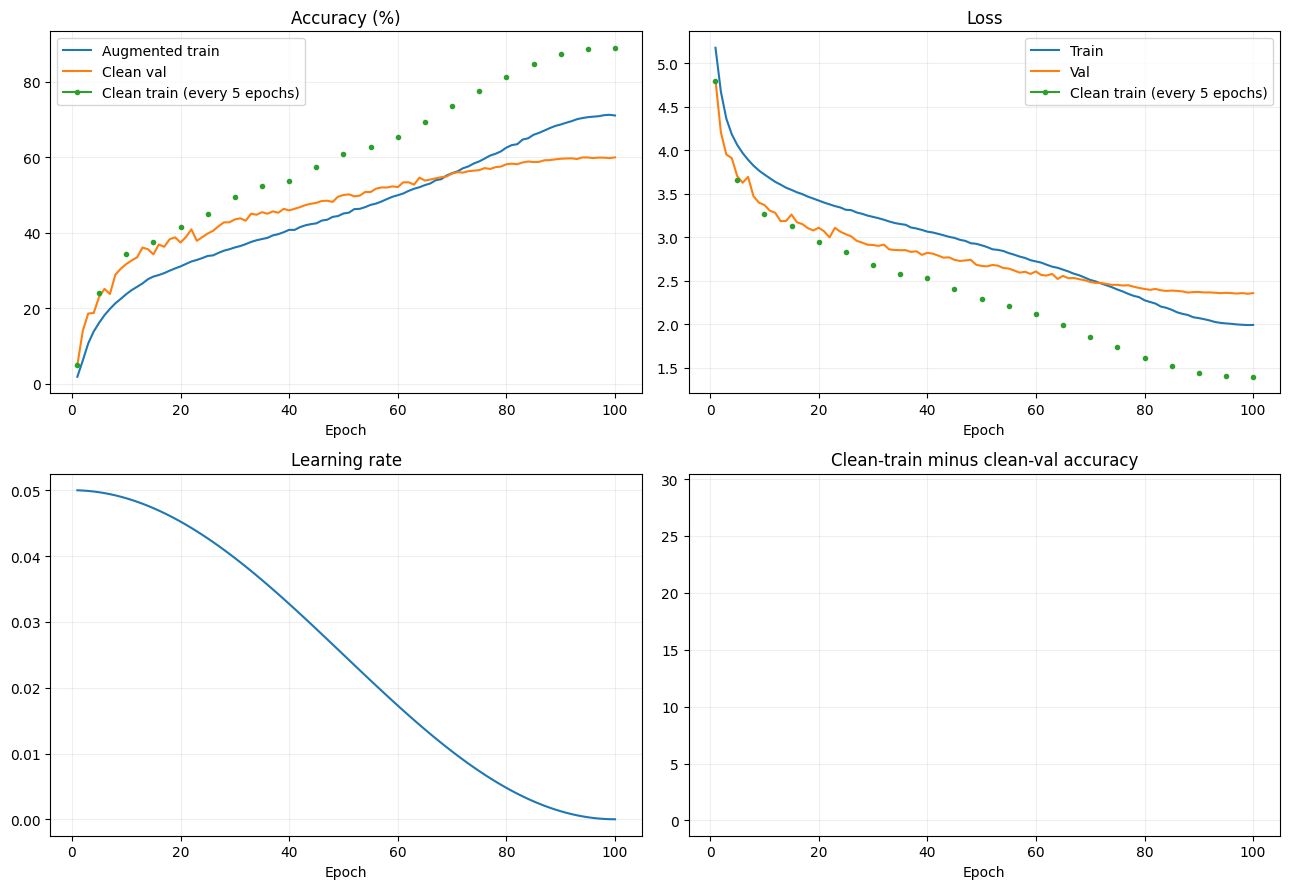

Eval:   0%|          | 0/1407 [00:00<?, ?it/s]

Eval:   0%|          | 0/313 [00:00<?, ?it/s]

Best checkpoint: clean train 88.97%, clean val 59.95%, gap 29.01 pp


In [14]:
h = pd.DataFrame(history)
fig, axs = plt.subplots(2, 2, figsize=(13, 9))
axs[0, 0].plot(h.epoch, h.train_acc, label='Augmented train')
axs[0, 0].plot(h.epoch, h.val_acc, label='Clean val')
axs[0, 0].plot(h.epoch, h.clean_train_acc, label='Clean train (every 5 epochs)', marker='o', markersize=3)
axs[0, 0].set_title('Accuracy (%)')
axs[0, 0].legend()
axs[0, 1].plot(h.epoch, h.train_loss, label='Train')
axs[0, 1].plot(h.epoch, h.val_loss, label='Val')
axs[0, 1].plot(h.epoch, h.clean_train_loss, label='Clean train (every 5 epochs)', marker='o', markersize=3)
axs[0, 1].set_title('Loss')
axs[0, 1].legend()
axs[1, 0].plot(h.epoch, h.lr)
axs[1, 0].set_title('Learning rate')
axs[1, 1].plot(h.epoch, h.generalization_gap)
axs[1, 1].set_title('Clean-train minus clean-val accuracy')
for ax in axs.flat: ax.set_xlabel('Epoch');ax.grid(alpha=.2)
plt.tight_layout()
plt.show()
# Clean train/validation gap uses the best checkpoint and identical no-augmentation transforms.
best = torch.load(BEST_PATH, map_location='cpu', weights_only=False)
raw_model().load_state_dict(best['model'])
clean_train_loss, clean_train_acc = run_epoch(clean_train_loader)
clean_val_loss, clean_val_acc = run_epoch(val_loader)
print(
    f'Best checkpoint: clean train {clean_train_acc:.2f}%, clean val {clean_val_acc:.2f}%, gap {clean_train_acc - clean_val_acc:.2f} pp')

## 7. Extract full validation features and class separation (256-D FC features)

In [15]:
@torch.no_grad()
def extract_features(loader):
    model.eval()
    ff = []
    yy = []
    for x, y in tqdm(loader, desc='Features'):
        _, f = model(x.to(DEVICE), return_features=True)
        ff.append(f.cpu().numpy())
        yy.append(y.numpy())
    return np.concatenate(ff), np.concatenate(yy)


features, labels = extract_features(val_loader)
print('Feature shape:', features.shape)
# Exact mean intra-class Euclidean distance to class centroid; inter-class mean centroid distance.
centroids = np.stack([features[labels == i].mean(0) for i in range(NUM_CLASSES)])
intra = np.mean([np.linalg.norm(features[labels == i] - centroids[i], axis=1).mean() for i in range(NUM_CLASSES)])
from scipy.spatial.distance import pdist

inter = pdist(centroids).mean()
print(
    f'Mean intra-class distance to centroid: {intra:.4f} | Mean inter-class centroid distance: {inter:.4f} | Ratio: {inter / intra:.4f}')
np.savez_compressed(SAVE_DIR / 'validation_features.npz', features=features, labels=labels, centroids=centroids)

Features:   0%|          | 0/313 [00:00<?, ?it/s]

Feature shape: (20000, 256)
Mean intra-class distance to centroid: 4.5870 | Mean inter-class centroid distance: 5.8532 | Ratio: 1.2760


# 2D t-SNE

Extracting 20-class features:   0%|          | 0/313 [00:00<?, ?it/s]

Feature shape: (2000, 256)
Feature dimension: 256
Label shape: (2000,)
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Number of classes: 20
2D feature shape: (2000, 2)


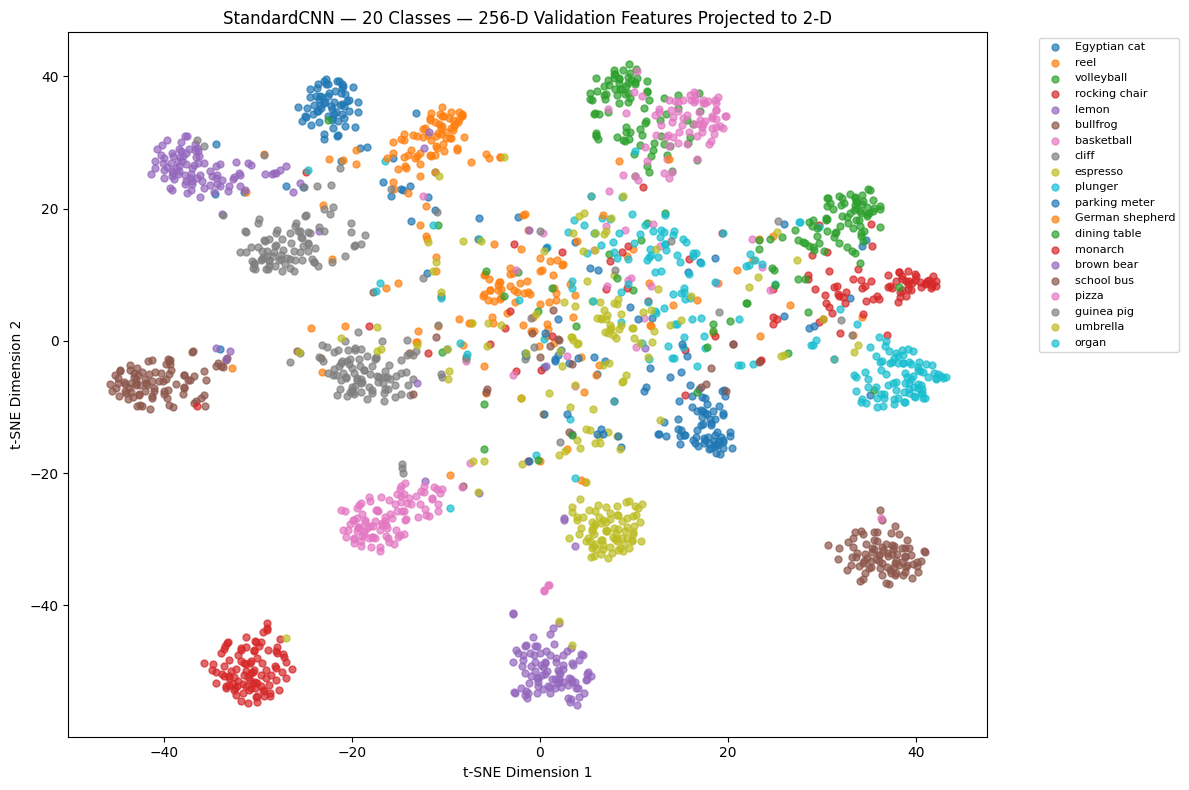

In [16]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm


# ============================================================
# SETTINGS
# ============================================================

NUM_TSNE_CLASSES = 20
TSNE_CLASS_IDS = list(range(NUM_TSNE_CLASSES))


# ============================================================
# Safe DataLoader for t-SNE
# Avoid macOS/Jupyter multiprocessing worker crash
# ============================================================

tsne_val_loader = DataLoader(
    val_subset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)


# ============================================================
# Extract features for selected 20 classes only
# ============================================================

@torch.inference_mode()
def extract_selected_features(
    model,
    data_loader,
    device,
    selected_class_ids
):
    model.eval()

    all_features = []
    all_labels = []

    selected_class_ids = set(selected_class_ids)

    for images, labels in tqdm(
        data_loader,
        desc="Extracting 20-class features"
    ):

        # Select only required classes
        mask = torch.tensor(
            [int(label) in selected_class_ids for label in labels],
            dtype=torch.bool
        )

        if not mask.any():
            continue

        images = images[mask].to(
            device,
            non_blocking=True
        )

        selected_labels = labels[mask]

        # StandardCNN:
        # return_features=True -> (logits, features)
        _, features = model(
            images,
            return_features=True
        )

        all_features.append(
            features.detach().cpu()
        )

        all_labels.append(
            selected_labels.cpu()
        )


    if len(all_features) == 0:
        raise RuntimeError(
            "No samples found for selected t-SNE classes."
        )


    features = torch.cat(
        all_features,
        dim=0
    ).numpy()

    labels = torch.cat(
        all_labels,
        dim=0
    ).numpy()

    return features, labels


# ============================================================
# Extract features
# ============================================================

tsne_features, tsne_labels = extract_selected_features(
    model=model,
    data_loader=tsne_val_loader,
    device=DEVICE,
    selected_class_ids=TSNE_CLASS_IDS
)


# ============================================================
# Automatically detect feature dimension
# ============================================================

FEATURE_DIM = tsne_features.shape[1]


print("Feature shape:", tsne_features.shape)
print("Feature dimension:", FEATURE_DIM)
print("Label shape:", tsne_labels.shape)
print("Classes:", np.unique(tsne_labels))
print(
    "Number of classes:",
    len(np.unique(tsne_labels))
)


# ============================================================
# 2D t-SNE
# ============================================================

tsne_2d = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1500,
    random_state=42
)

features_2d = tsne_2d.fit_transform(
    tsne_features
)

print(
    "2D feature shape:",
    features_2d.shape
)


# ============================================================
# Plot
# ============================================================

plt.figure(
    figsize=(12, 8)
)


for class_id in TSNE_CLASS_IDS:

    mask = tsne_labels == class_id

    if not np.any(mask):
        continue

    plt.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        s=25,
        alpha=0.70,
        label=CLASS_NAMES[class_id]
    )


plt.xlabel(
    "t-SNE Dimension 1"
)

plt.ylabel(
    "t-SNE Dimension 2"
)


plt.title(
    f"StandardCNN — 20 Classes — "
    f"{FEATURE_DIM}-D Validation Features Projected to 2-D"
)


plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)


plt.tight_layout()
plt.show()

In [ ]:
from sklearn.manifold import TSNE
import pandas as pd
import plotly.express as px
from IPython.display import HTML, display


# ============================================================
# Automatically detect feature dimension
# ============================================================

FEATURE_DIM = tsne_features.shape[1]

print(
    "Input feature shape:",
    tsne_features.shape
)

print(
    "Feature dimension:",
    FEATURE_DIM
)


# ============================================================
# 3D t-SNE
# ============================================================

tsne_3d = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1500,
    random_state=42
)


features_3d = tsne_3d.fit_transform(
    tsne_features
)


print(
    "3D feature shape:",
    features_3d.shape
)


# ============================================================
# Create DataFrame
# ============================================================

tsne_df = pd.DataFrame({

    "Dim1": features_3d[:, 0],
    "Dim2": features_3d[:, 1],
    "Dim3": features_3d[:, 2],

    "Class_ID": tsne_labels,

    "Class": [
        CLASS_NAMES[int(label)]
        for label in tsne_labels
    ]
})


# ============================================================
# Interactive 3D t-SNE
# ============================================================

fig = px.scatter_3d(

    tsne_df,

    x="Dim1",
    y="Dim2",
    z="Dim3",

    color="Class",

    hover_data={
        "Class_ID": True,
        "Class": True,
        "Dim1": False,
        "Dim2": False,
        "Dim3": False
    },

    opacity=0.75,

    title=(
        f"StandardCNN — 20 Classes — "
        f"{FEATURE_DIM}-D Validation Features Projected to 3-D"
    )
)


fig.update_traces(
    marker=dict(
        size=4
    )
)


fig.update_layout(

    width=950,
    height=700,

    scene=dict(

        xaxis_title="t-SNE Dimension 1",

        yaxis_title="t-SNE Dimension 2",

        zaxis_title="t-SNE Dimension 3"
    ),

    legend=dict(
        title="Class",
        font=dict(size=9)
    )
)


display(
    HTML(
        fig.to_html(
            include_plotlyjs=True,
            full_html=False
        )
    )
)